# Practico 2 - Redes Bayesianas y Estimación de distribuciones continuas.

El objetivo de esta notebook es implementar las redes bayesianas sobre el dataset de Tennis y continuar explorando formas de estimar distribuciones pero esta vez sobre datos continuos. 

## Parte 1: Redes Bayesianas

## Imports

In [1]:
#!pip install pgmpy

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

c:\Users\Enrique\anaconda3\envs\IAGenerativaPracticos\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Paso 1: Cargar los Datos y Construir el Modelo

In [3]:
# Cargar los datos
data = pd.read_csv('./tennis.csv')
data.head()

,Day,Outlook,Temp,Humidity,Wind,Tennis
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


Definimos variables aleatorias que vamos a usar. Por simplicidad en la visualización solo usaremos 3, pero puede usar todas las que quiera.

In [4]:
outlook = 'Outlook'
temp = 'Temp'
wind = 'Wind'
tennis = 'Tennis'

data = data[[outlook, temp, tennis]]

Tenemos que definir las relaciones condicionales que hay entre estas variables, para eso vamos a definir las siguientes relaciones: 

- Tennis depende de Outlook
- Tennis depende de Temp

In [5]:
relations = [(outlook, tennis), (temp, tennis)]

Teniendo las relaciones vamos a crear nuestro modelo!

In [6]:
model = DiscreteBayesianNetwork(relations)

Ahora que tenemos el modelo vamos a ajustarlo para que capture las probabilidades condicionales en las observaciones.

In [7]:
# Aprender los CPDs desde los datos
model.fit(data, estimator=MaximumLikelihoodEstimator)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Outlook': 'C', 'Temp': 'C', 'Tennis': 'C'}


Verificamos si el modelo es valido.

In [8]:
model.check_model()

True

### Paso 2: Visualización del Grafo y CPDs

In [9]:
def visualize_graph(model):
    G = nx.DiGraph()
    G.add_edges_from(model.edges())
    plt.figure(figsize=(7, 5))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=10000, node_color="skyblue", font_size=14, font_weight="bold", arrowsize=30)
    plt.title("Red Bayesiana del Dataset de Tenis")
    plt.show()

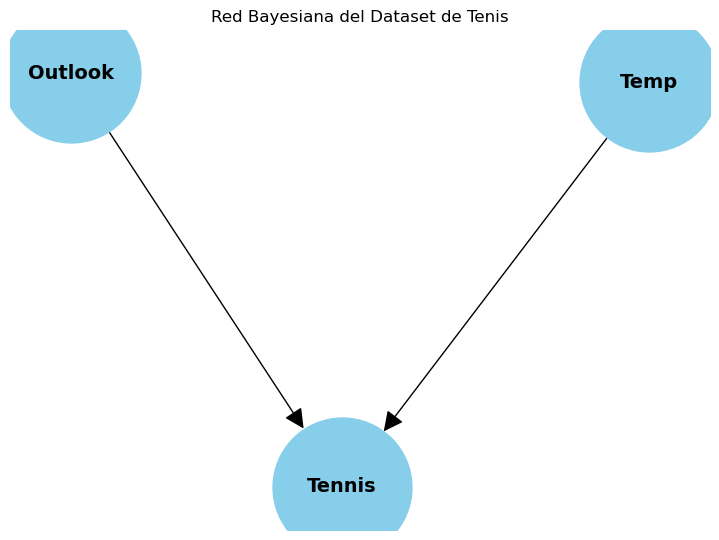

In [10]:
visualize_graph(model)

In [11]:
for cpd in model.get_cpds():
    print(f"CPD de {cpd.variable}:")
    print(cpd)

CPD de Outlook:
+-------------------+----------+
| Outlook(Overcast) | 0.285714 |
+-------------------+----------+
| Outlook(Rain)     | 0.357143 |
+-------------------+----------+
| Outlook(Sunny)    | 0.357143 |
+-------------------+----------+
CPD de Tennis:
+-------------+-------------------+-----+----------------+----------------+
| Outlook     | Outlook(Overcast) | ... | Outlook(Sunny) | Outlook(Sunny) |
+-------------+-------------------+-----+----------------+----------------+
| Temp        | Temp(Cool)        | ... | Temp(Hot)      | Temp(Mild)     |
+-------------+-------------------+-----+----------------+----------------+
| Tennis(No)  | 0.0               | ... | 1.0            | 0.5            |
+-------------+-------------------+-----+----------------+----------------+
| Tennis(Yes) | 1.0               | ... | 0.0            | 0.5            |
+-------------+-------------------+-----+----------------+----------------+
CPD de Temp:
+------------+----------+
| Temp(Cool) | 

### Explicación:
- **Estructura de la Red:** Los arcos en la red representan la relación de causa y efecto entre las variables. Aquí, las condiciones del clima influyen en la decisión de jugar tenis.
- **CPDs:** Cada nodo tiene un CPD que describe la distribución de probabilidad condicional de la variable dada sus padres.

¿Por qué la tabla de Outlook y Temp solamente una columna mientras que la de Tennis tiene varias?

Outlook y Temp tienen una sola columna porque no dependen de ninguna otra variable, solo muestran la probabilidad de cada uno de sus estados. Tennis tiene varias columnas porque depende de Outlook y Temp, entonces tiene que mostrar la probabilidad para cada combinación posible de los valores de sus padres.

¿Cuántas columnas tiene la de Tennis? ¿Por qué?

Tennis tiene 6 columnas. Esto es porque Outlook tiene 3 estados (Sunny, Overcast, Rain) y Temp tiene 3 estados (Hot, Mild, Cool), entonces 3 x 3 = 9 combinaciones posibles. Pero como estamos usando solo 3 variables en el modelo (Outlook, Temp, Tennis), la tabla muestra las probabilidades condicionales para cada combinación de los padres.

In [12]:
for cpd in model.get_cpds():
    print(f"Variable: {cpd.variable}")
    print("  Estados:")
    for state in cpd.state_names[cpd.variable]:
        print(f"    - {state}")
    print(f"  Cardinalidad: {cpd.variable_card}\n")

Variable: Outlook
  Estados:
    - Overcast
    - Rain
    - Sunny
  Cardinalidad: 3

Variable: Tennis
  Estados:
    - No
    - Yes
  Cardinalidad: 2

Variable: Temp
  Estados:
    - Cool
    - Hot
    - Mild
  Cardinalidad: 3



- **Cardinalidad:** Indica cuántos estados puede tener una variable.

### Paso 3: Inferencia en la Red

**Inferencia:** Dado un conjunto de evidencias (ej. Outlook y Temp), la red calcula la probabilidad de que Tennis sea 'Yes' o 'No'.

In [13]:
# Inferencia en la red bayesiana
inferencia = VariableElimination(model)
resultado = inferencia.query(variables=[tennis], evidence={outlook: 'Sunny', temp: 'Mild'})
print("\nResultado de la inferencia:")
print(resultado)


Resultado de la inferencia:
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.5000 |
+-------------+---------------+
| Tennis(Yes) |        0.5000 |
+-------------+---------------+


### Ejercicios:
1. Realice inferencias usando diferentes combinaciones de evidencias para observar cómo cambian las probabilidades.
2. Cree otro modelo con diferentes relaciones y realice inferencias sobre este.
 Recuerde que puede agregar más variables (como por ej. Humudity o Wind).

In [14]:
print("Experimento 1: Inferencia con diferentes combinaciones de evidencias\n")

print("Caso 1: Outlook=Rain, Temp=Cool")
resultado1 = inferencia.query(variables=[tennis], evidence={outlook: 'Rain', temp: 'Cool'})
print(resultado1)

print("\n" + "="*50)
print("Caso 2: Outlook=Overcast, Temp=Hot")
resultado2 = inferencia.query(variables=[tennis], evidence={outlook: 'Overcast', temp: 'Hot'})
print(resultado2)

print("\n" + "="*50)
print("Caso 3: Outlook=Sunny, Temp=Cool")
resultado3 = inferencia.query(variables=[tennis], evidence={outlook: 'Sunny', temp: 'Cool'})
print(resultado3)

Experimento 1: Inferencia con diferentes combinaciones de evidencias

Caso 1: Outlook=Rain, Temp=Cool
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.5000 |
+-------------+---------------+
| Tennis(Yes) |        0.5000 |
+-------------+---------------+

Caso 2: Outlook=Overcast, Temp=Hot
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.0000 |
+-------------+---------------+
| Tennis(Yes) |        1.0000 |
+-------------+---------------+

Caso 3: Outlook=Sunny, Temp=Cool
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.0000 |
+-------------+---------------+
| Tennis(Yes) |        1.0000 |
+-------------+---------------+


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Outlook': 'C', 'Temp': 'C', 'Humidity': 'C', 'Wind': 'C', 'Tennis': 'C'}



Experimento 2: Modelo con todas las variables

Modelo creado con todas las variables
Variables: ['Outlook', 'Tennis', 'Temp', 'Humidity', 'Wind']
Relaciones: [('Outlook', 'Tennis'), ('Temp', 'Tennis'), ('Humidity', 'Tennis'), ('Wind', 'Tennis')]


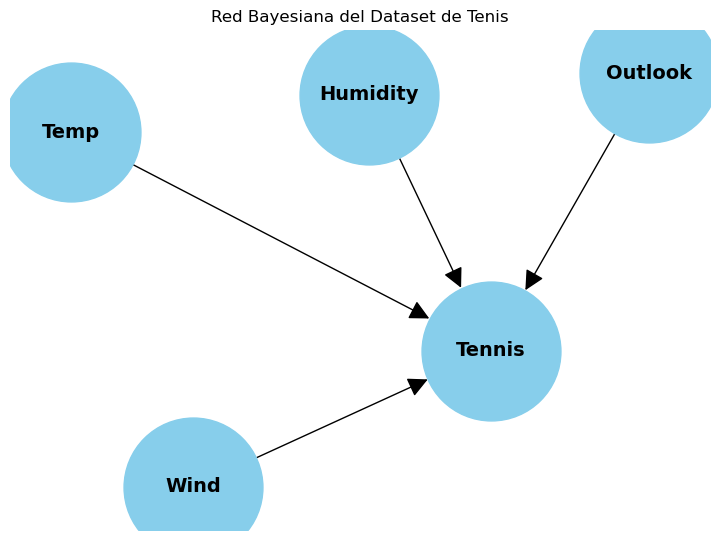

In [15]:
print("\nExperimento 2: Modelo con todas las variables\n")

data_completa = pd.read_csv('./tennis.csv')
data_completa = data_completa[['Outlook', 'Temp', 'Humidity', 'Wind', 'Tennis']]

relations_completas = [
    ('Outlook', 'Tennis'),
    ('Temp', 'Tennis'),
    ('Humidity', 'Tennis'),
    ('Wind', 'Tennis')
]

model2 = DiscreteBayesianNetwork(relations_completas)
model2.fit(data_completa, estimator=MaximumLikelihoodEstimator)

print("Modelo creado con todas las variables")
print(f"Variables: {model2.nodes()}")
print(f"Relaciones: {model2.edges()}")

visualize_graph(model2)

In [16]:
inferencia2 = VariableElimination(model2)

print("\nInferencia con el modelo completo:")
print("\nCaso: Outlook=Sunny, Temp=Hot, Humidity=High, Wind=Weak")
resultado_completo = inferencia2.query(
    variables=['Tennis'], 
    evidence={'Outlook': 'Sunny', 'Temp': 'Hot', 'Humidity': 'High', 'Wind': 'Weak'}
)
print(resultado_completo)

print("\n" + "="*50)
print("Caso: Outlook=Overcast, Temp=Mild, Humidity=Normal, Wind=Strong")
resultado_completo2 = inferencia2.query(
    variables=['Tennis'], 
    evidence={'Outlook': 'Overcast', 'Temp': 'Mild', 'Humidity': 'Normal', 'Wind': 'Strong'}
)
print(resultado_completo2)


Inferencia con el modelo completo:

Caso: Outlook=Sunny, Temp=Hot, Humidity=High, Wind=Weak
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        1.0000 |
+-------------+---------------+
| Tennis(Yes) |        0.0000 |
+-------------+---------------+

Caso: Outlook=Overcast, Temp=Mild, Humidity=Normal, Wind=Strong
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.5000 |
+-------------+---------------+
| Tennis(Yes) |        0.5000 |
+-------------+---------------+


## Parte 2: Estimando distribuciones continuas.

El objetivo de esta notebook es explorar una primera manera de aproximar $p(x|y)$ y $p(y|x)$ en un dataset tabular donde $x\in\mathbb{R}^k$ y el objetivo $y$ es una variable discreta y finita $y\in\{0,\ldots,d\}⊆\mathbb{N}, d\geq 1$.

### Imports

In [17]:
import numpy as np
import seaborn as sns
import os

from sklearn import datasets
from matplotlib import pyplot as plt

os.makedirs("./imgs", exist_ok=True)

### Cargamos el dataset

In [18]:
iris = datasets.load_iris()

In [19]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [20]:
X = iris.data
y = iris.target

In [21]:
iris_df = pd.DataFrame(data=X,
             columns=iris.feature_names,
             )

iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Para simplificar el problema solo trabajaremos con una variable aleatoria.

Filtramos el dataset por feature.

feature_number puede ser 0, 1, 2, 3
- 0 - sepal length (cm)
- 1 - sepal width (cm)
- 2 - petal length (cm)
- 3 - petal width (cm)

In [22]:
feature_number = 0
feature_name = iris.feature_names[feature_number]
xfeature_original = X[:,feature_number]
xfeature_original

array([5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8,
       4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. ,
       5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. , 5.5, 4.9, 4.4,
       5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. , 7. , 6.4,
       6.9, 5.5, 6.5, 5.7, 6.3, 4.9, 6.6, 5.2, 5. , 5.9, 6. , 6.1, 5.6,
       6.7, 5.6, 5.8, 6.2, 5.6, 5.9, 6.1, 6.3, 6.1, 6.4, 6.6, 6.8, 6.7,
       6. , 5.7, 5.5, 5.5, 5.8, 6. , 5.4, 6. , 6.7, 6.3, 5.6, 5.5, 5.5,
       6.1, 5.8, 5. , 5.6, 5.7, 5.7, 6.2, 5.1, 5.7, 6.3, 5.8, 7.1, 6.3,
       6.5, 7.6, 4.9, 7.3, 6.7, 7.2, 6.5, 6.4, 6.8, 5.7, 5.8, 6.4, 6.5,
       7.7, 7.7, 6. , 6.9, 5.6, 7.7, 6.3, 6.7, 7.2, 6.2, 6.1, 6.4, 7.2,
       7.4, 7.9, 6.4, 6.3, 6.1, 7.7, 6.3, 6.4, 6. , 6.9, 6.7, 6.9, 5.8,
       6.8, 6.7, 6.7, 6.3, 6.5, 6.2, 5.9])

Como estamos trabajando con valores continuos, vamos a discretizarlos.

Para ello, vamos a utilizar la funcion linspace de numpy, que nos permite dividir un rango en n partes iguales. https://numpy.org/doc/stable/reference/generated/numpy.linspace.html

Hacemos el siguiente calculo para tener la cantidad de bins que deseamos ya que la librería siempre nos crea uno más.

In [23]:
NBINS = 10
bin_size = (np.max(xfeature_original) - np.min(xfeature_original)) / NBINS
end = np.max(xfeature_original) - bin_size
bins = np.linspace(start=np.min(xfeature_original), stop=end, num=NBINS)

bins

array([4.3 , 4.66, 5.02, 5.38, 5.74, 6.1 , 6.46, 6.82, 7.18, 7.54])

In [24]:
xfeature_digitized = np.digitize(x=xfeature_original, bins=bins)
xfeature_digitized

array([ 3,  2,  2,  1,  2,  4,  1,  2,  1,  2,  4,  2,  2,  1,  5,  4,  4,
        3,  4,  3,  4,  3,  1,  3,  2,  2,  2,  3,  3,  2,  2,  4,  3,  4,
        2,  2,  4,  2,  1,  3,  2,  1,  1,  2,  3,  2,  3,  1,  3,  2,  8,
        6,  8,  4,  7,  4,  6,  2,  7,  3,  2,  5,  5,  6,  4,  7,  4,  5,
        6,  4,  5,  6,  6,  6,  6,  7,  7,  7,  5,  4,  4,  4,  5,  5,  4,
        5,  7,  6,  4,  4,  4,  6,  5,  2,  4,  4,  4,  6,  3,  4,  6,  5,
        8,  6,  7, 10,  2,  9,  7,  9,  7,  6,  7,  4,  5,  6,  7, 10, 10,
        5,  8,  4, 10,  6,  7,  9,  6,  6,  6,  9,  9, 10,  6,  6,  6, 10,
        6,  6,  5,  8,  7,  8,  5,  7,  7,  7,  6,  7,  6,  5])

### Aproximamos $p(x|y)$

Para calcular la distribución $p (x | y)$ usamos *distplot kde* (Kernel Density Estimation) para cada clase con los datos originales (datos continuos y no los discretizados).

Para este paso aprovechamos que el dataset esta ordenado por clase.

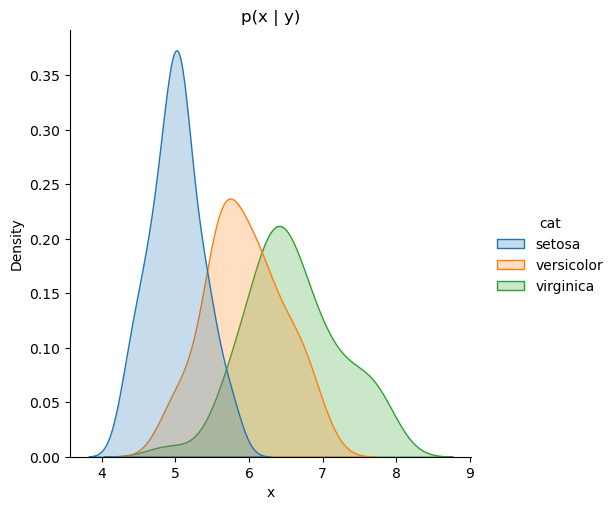

In [25]:
pd_cats = pd.DataFrame(xfeature_original.flatten(), columns=['x'])
pd_cats['cat'] = np.concatenate((np.full(50, 'setosa'),
                                np.full(50, 'versicolor'),
                                np.full(50, 'virginica')))
sns.displot(
    data=pd_cats, x='x', kind='kde',
    hue='cat', fill=True
)

plt.title('p(x | y)')
plt.savefig('./imgs/p_x_dado_y_original.png')
plt.show()

¿Qué nos muestra esta gráfica?

La gráfica muestra cómo se distribuyen los valores del largo del sépalo para cada tipo de flor. Vemos tres curvas, una para cada clase de flor.

¿Qué conclusiones puede sacar?

Podemos ver que las tres clases de flores tienen distribuciones diferentes. Las setosa tienden a tener sépalos más cortos, las versicolor están en el medio, y las virginica tienen sépalos más largos. Las curvas se solapan un poco, lo que significa que hay algunos valores donde podríamos confundir una clase con otra.

Ejercicio: Grafique un histograma para cada clase que nos muestre $p (bin| y = clase)$ utilizando los datos discretizados. Puede utilizar la función *np.histogram*. https://numpy.org/doc/stable/reference/generated/numpy.histogram.html

Luego compare los histogramas con la gráfica de arriba sobre $p (x | y)$.

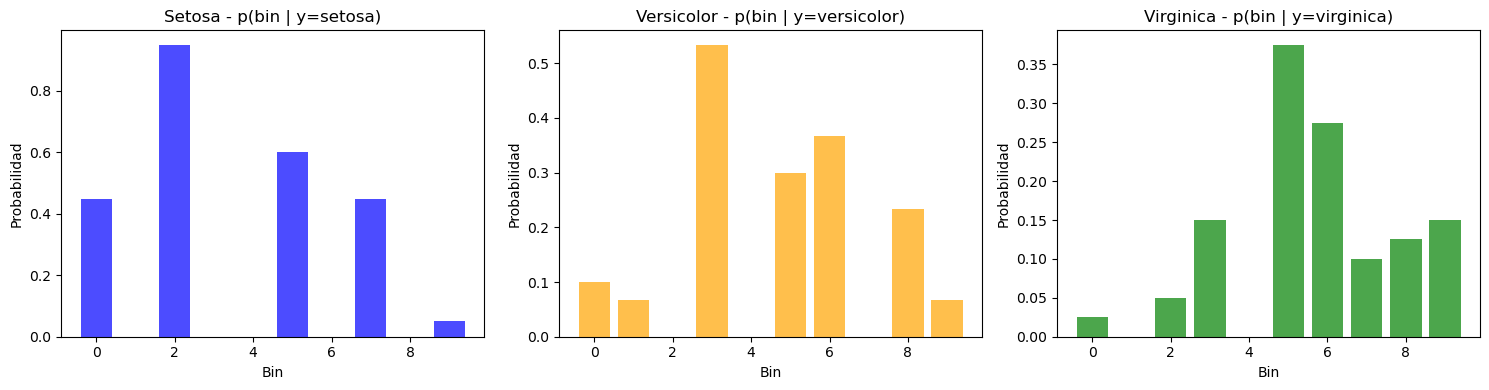

In [36]:
setosa_digitized = xfeature_digitized[:50]
versicolor_digitized = xfeature_digitized[50:100]
virginica_digitized = xfeature_digitized[100:150]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hist_setosa, bins_hist = np.histogram(setosa_digitized, bins=NBINS, density=True)
axes[0].bar(range(len(hist_setosa)), hist_setosa, color='blue', alpha=0.7)
axes[0].set_title('Setosa - p(bin | y=setosa)')
axes[0].set_xlabel('Bin')
axes[0].set_ylabel('Probabilidad')

hist_versicolor, _ = np.histogram(versicolor_digitized, bins=NBINS, density=True)
axes[1].bar(range(len(hist_versicolor)), hist_versicolor, color='orange', alpha=0.7)
axes[1].set_title('Versicolor - p(bin | y=versicolor)')
axes[1].set_xlabel('Bin')
axes[1].set_ylabel('Probabilidad')

hist_virginica, _ = np.histogram(virginica_digitized, bins=NBINS, density=True)
axes[2].bar(range(len(hist_virginica)), hist_virginica, color='green', alpha=0.7)
axes[2].set_title('Virginica - p(bin | y=virginica)')
axes[2].set_xlabel('Bin')
axes[2].set_ylabel('Probabilidad')

plt.tight_layout()
plt.savefig('./imgs/histogramas_discretizados.png')
plt.show()

Estos histogramas muestran la distribucion discreta de los bins para cada clase.
Comparando con la grafica KDE original, vemos que capturan la misma tendencia general:
- Setosa tiene valores mas bajos (bins mas a la izquierda)
- Versicolor tiene valores intermedios
- Virginica tiene valores mas altos (bins mas a la derecha)
La diferencia es que los histogramas son discretos mientras que el KDE es continuo.

### Aproximamos $p(y|x)$

Estime la probabilidad condicional de *y* dado *x* y luego muestree 10 valores de y dado que $x = 4.75$

In [27]:
setosa_data = xfeature_original[:50]
versicolor_data = xfeature_original[50:100]
virginica_data = xfeature_original[100:150]

mean_setosa_temp = np.mean(setosa_data)
std_setosa_temp = np.std(setosa_data)
mean_versicolor_temp = np.mean(versicolor_data)
std_versicolor_temp = np.std(versicolor_data)
mean_virginica_temp = np.mean(virginica_data)
std_virginica_temp = np.std(virginica_data)

x_val = 4.75

prob_x_dado_setosa = (1 / (std_setosa_temp * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_val - mean_setosa_temp) / std_setosa_temp) ** 2)
prob_x_dado_versicolor = (1 / (std_versicolor_temp * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_val - mean_versicolor_temp) / std_versicolor_temp) ** 2)
prob_x_dado_virginica = (1 / (std_virginica_temp * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_val - mean_virginica_temp) / std_virginica_temp) ** 2)

prior_setosa = 1/3
prior_versicolor = 1/3
prior_virginica = 1/3

numerador_setosa = prob_x_dado_setosa * prior_setosa
numerador_versicolor = prob_x_dado_versicolor * prior_versicolor
numerador_virginica = prob_x_dado_virginica * prior_virginica

denominador = numerador_setosa + numerador_versicolor + numerador_virginica

prob_setosa_dado_x = numerador_setosa / denominador
prob_versicolor_dado_x = numerador_versicolor / denominador
prob_virginica_dado_x = numerador_virginica / denominador

print(f"Estimacion de p(y | x={x_val}):")
print(f"p(y=setosa | x={x_val}) = {prob_setosa_dado_x:.4f}")
print(f"p(y=versicolor | x={x_val}) = {prob_versicolor_dado_x:.4f}")
print(f"p(y=virginica | x={x_val}) = {prob_virginica_dado_x:.4f}")
print(f"Suma total: {prob_setosa_dado_x + prob_versicolor_dado_x + prob_virginica_dado_x:.4f}")

clases_y = ['setosa', 'versicolor', 'virginica']
probs_y = [prob_setosa_dado_x, prob_versicolor_dado_x, prob_virginica_dado_x]

muestras_y = np.random.choice(clases_y, size=10, p=probs_y)
print(f"\n10 muestras de y dado x={x_val}:")
print(muestras_y)

unique, counts = np.unique(muestras_y, return_counts=True)
print(f"\nDistribucion de las muestras: {dict(zip(unique, counts))}")

Estimacion de p(y | x=4.75):
p(y=setosa | x=4.75) = 0.9340
p(y=versicolor | x=4.75) = 0.0565
p(y=virginica | x=4.75) = 0.0095
Suma total: 1.0000

10 muestras de y dado x=4.75:
['setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa'
 'setosa' 'setosa']

Distribucion de las muestras: {np.str_('setosa'): np.int64(10)}


### Sampleamos sobre *p(x|y)*

Realice una muestra de 50 valores de $x$ para cada valor de $y$. Recomendamos utilizar la función *gaussian_kde* de *scipy.stats*.

In [28]:
from scipy.stats import gaussian_kde


Grafique $p(x|y)$ utilizando los datos sampleados y compare con la gráfica de $p(x|y)$ creada con los datos originales.

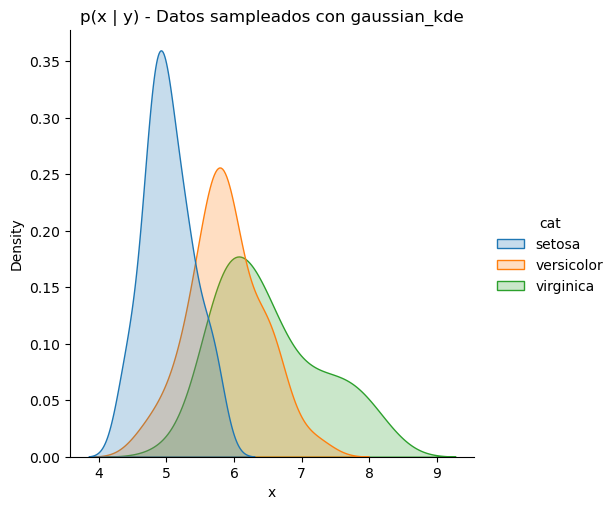

In [29]:
setosa_data_temp = xfeature_original[:50]
versicolor_data_temp = xfeature_original[50:100]
virginica_data_temp = xfeature_original[100:150]

setosa_samples = gaussian_kde(setosa_data_temp).resample(size=50).flatten()
versicolor_samples = gaussian_kde(versicolor_data_temp).resample(size=50).flatten()
virginica_samples = gaussian_kde(virginica_data_temp).resample(size=50).flatten()

pd_cats_sampled = pd.DataFrame({
    'x': np.concatenate([setosa_samples, versicolor_samples, virginica_samples]),
    'cat': np.concatenate([np.full(50, 'setosa'), np.full(50, 'versicolor'), np.full(50, 'virginica')])
})

sns.displot(data=pd_cats_sampled, x='x', kind='kde', hue='cat', fill=True)
plt.title('p(x | y) - Datos sampleados con gaussian_kde')
plt.savefig('./imgs/p_x_dado_y_sampled.png')
plt.show()

### Aproximamos la distribución normal de $p(x|y)$

In [30]:
# Separamos los datos de cada clase
setosa_feature = xfeature_original[:50]
versicolor_feature = xfeature_original[50:100]
virginica_feature = xfeature_original[100:150]

Calcule la media y la desviación estándar para cada valor de $y$.

In [31]:
mean_setosa = np.mean(setosa_feature)
std_setosa = np.std(setosa_feature)

mean_versicolor = np.mean(versicolor_feature)
std_versicolor = np.std(versicolor_feature)

mean_virginica = np.mean(virginica_feature)
std_virginica = np.std(virginica_feature)

print(f"Setosa - Media: {mean_setosa:.2f}, Std: {std_setosa:.2f}")
print(f"Versicolor - Media: {mean_versicolor:.2f}, Std: {std_versicolor:.2f}")
print(f"Virginica - Media: {mean_virginica:.2f}, Std: {std_virginica:.2f}")

Setosa - Media: 5.01, Std: 0.35
Versicolor - Media: 5.94, Std: 0.51
Virginica - Media: 6.59, Std: 0.63


Utilice la función *normal* de *np.random* para realizar una muestra sobre cada distribución normal.

In [32]:
setosa_normal_samples = np.random.normal(mean_setosa, std_setosa, 50)
versicolor_normal_samples = np.random.normal(mean_versicolor, std_versicolor, 50)
virginica_normal_samples = np.random.normal(mean_virginica, std_virginica, 50)

Utilizando las muestras grafique la aproximación a distribuciones normales de *p (x | y)*.

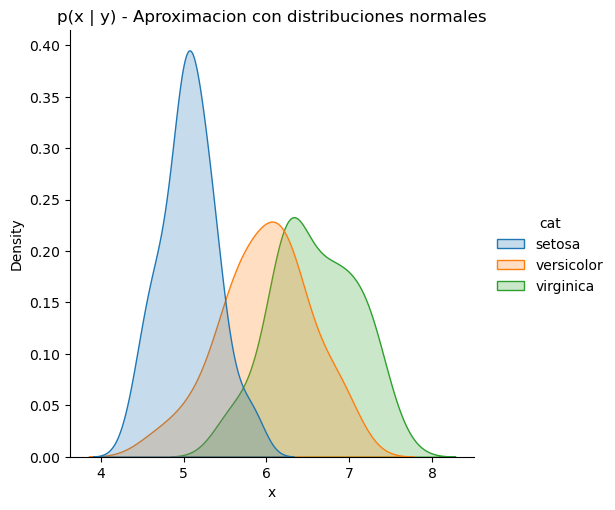

In [33]:
pd_cats_normal = pd.DataFrame({
    'x': np.concatenate([setosa_normal_samples, versicolor_normal_samples, virginica_normal_samples]),
    'cat': np.concatenate([np.full(50, 'setosa'), np.full(50, 'versicolor'), np.full(50, 'virginica')])
})

sns.displot(data=pd_cats_normal, x='x', kind='kde', hue='cat', fill=True)
plt.title('p(x | y) - Aproximacion con distribuciones normales')
plt.savefig('./imgs/p_x_dado_y_normal.png')
plt.show()

Compare esta gráfica con la gráfica de p(x|y) original.

Las distribuciones aproximadas con normales se ven bastante similares a las originales, pero un poco más suaves y simétricas. Las normales asumen que los datos tienen forma de campana perfecta, lo cual es una simplificación de la realidad.

### Graficamos la mezcla de Gaussianas.

Grafique la mezcla de Gaussianas.

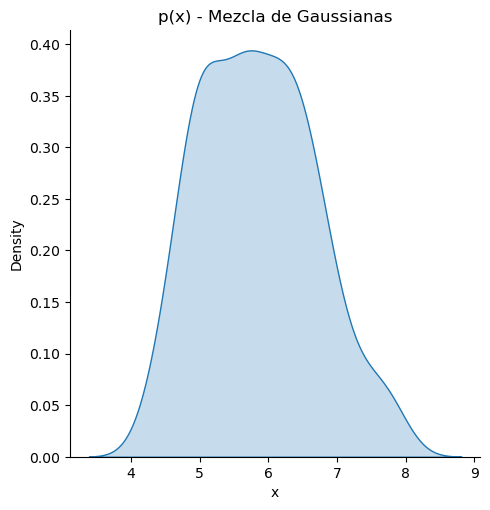

In [34]:
sns.displot(data=pd_cats, x='x', kind='kde', fill=True)
plt.title('p(x) - Mezcla de Gaussianas')
plt.savefig('./imgs/p_x_mezcla.png')
plt.show()

Compare esta gráfica con la gráfica de p(x|y) usando distribuciones normales.

La mezcla de gaussianas muestra la distribución marginal de x sin condicionar por la clase. Vemos una sola curva en lugar de tres separadas. Esta curva tiene varios picos o modas porque combina las tres distribuciones condicionales de las clases, reflejando que hay tres grupos diferentes de flores con características distintas.

### Opcional: Aproxime $p(y|x)$ y realice una muestra de 10 valores de $y$ con $x = 4.75$

In [38]:
x_value = 4.75

p_y_dado_x_setosa = (1/3) * (1 / (std_setosa * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_value - mean_setosa) / std_setosa) ** 2)
p_y_dado_x_versicolor = (1/3) * (1 / (std_versicolor * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_value - mean_versicolor) / std_versicolor) ** 2)
p_y_dado_x_virginica = (1/3) * (1 / (std_virginica * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_value - mean_virginica) / std_virginica) ** 2)

total = p_y_dado_x_setosa + p_y_dado_x_versicolor + p_y_dado_x_virginica

p_setosa = p_y_dado_x_setosa / total
p_versicolor = p_y_dado_x_versicolor / total
p_virginica = p_y_dado_x_virginica / total

print(f"p(y=setosa | x=4.75) = {p_setosa:.4f}")
print(f"p(y=versicolor | x=4.75) = {p_versicolor:.4f}")
print(f"p(y=virginica | x=4.75) = {p_virginica:.4f}")

clases = ['setosa', 'versicolor', 'virginica']
probabilidades = [p_setosa, p_versicolor, p_virginica]

samples_y = np.random.choice(clases, size=10, p=probabilidades)
print(f"\n10 muestras de y dado x=4.75: {samples_y}")

p(y=setosa | x=4.75) = 0.9340
p(y=versicolor | x=4.75) = 0.0565
p(y=virginica | x=4.75) = 0.0095

10 muestras de y dado x=4.75: ['versicolor' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa'
 'setosa' 'setosa' 'setosa']


Observacion: Como x=4.75 esta muy cerca de la media de setosa (5.01), la probabilidad de que sea setosa es mucho mayor (93.4%). Las muestras reflejan esto, saliendo casi todas setosa.